# Per-Attack Category Analysis

**Research questions addressed:**  
> RQ3: For which attack types does eBPF provide the greatest advantage?  
> RQ4: What are the computational trade-offs of eBPF-enhanced detection?  

**Split usage in this notebook:**
- Load the **saved Split 4 headline artifact from Notebook 01**.
- Evaluate per-attack behaviour on **Split 4 `test_realistic.parquet`** only.
- Treat this notebook as a **supporting breakdown of the headline Split 4 result**, not a separate model-selection stage.

**What this notebook produces:**
1. Per-attack detection rate: baseline vs eBPF for the selected headline model family
2. Delta detection rate visualisations for Split 4 realistic
3. Inference latency and memory benchmarks for the saved headline artifacts

**Prerequisite:** Run Notebooks 00 and 01 first.


In [1]:
import os, sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tracemalloc

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *
from ml.notebooks.modeling_pipeline import load_model_pack, prepare_split, align_to_features, per_attack_detection_rates

PACKS = {
    'baseline': load_model_pack('baseline', artifact='headline', seed=RANDOM_SEED),
    'ebpf': load_model_pack('ebpf', artifact='headline', seed=RANDOM_SEED),
}

DATA = {}
for fs, split4 in [('baseline', SPLITS_4_BASELINE), ('ebpf', SPLITS_4_EBPF)]:
    te_df = pd.read_parquet(split4 / 'test_realistic.parquet')
    prep = prepare_split(te_df, feature_list=PACKS[fs]['features'])
    X = align_to_features(prep.X, PACKS[fs]['features'])
    DATA[fs] = {'X': X, 'y': prep.y, 'labels': prep.labels}
    print(f"[*] {fs}: model={PACKS[fs]['selected_model_name']} rows={len(X):,}")


[*] baseline: model=hgb_balanced rows=546,207
[*] ebpf: model=hgb_balanced rows=546,207


## Load saved headline artifacts and Split 4 realistic test data


In [2]:
attack_tables = {}
for fs in ['baseline', 'ebpf']:
    model = PACKS[fs]['model']
    d = DATA[fs]
    # Use the val-tuned threshold stored in the pack (if available)
    stored_thr = PACKS[fs].get('threshold', None)
    if stored_thr is not None and hasattr(model, 'predict_proba'):
        prob = model.predict_proba(d['X'])[:, 1]
        y_pred = (prob >= stored_thr).astype(int)
        # Manual per-attack computation using tuned threshold
        rows_tbl = []
        BENIGN_LIKE = {"BENIGN", "Unknown", "nan", "NaN", ""}
        for attack in sorted(d['labels'].unique()):
            if attack in BENIGN_LIKE: continue
            mask = (d['labels'] == attack).to_numpy()
            n = int(mask.sum())
            if n == 0: continue
            det = int((y_pred[mask] == 1).sum())
            rows_tbl.append({'attack': attack, 'n': n, 'detected': det,
                              'detection_rate': float(det / max(n, 1))})
        tbl = pd.DataFrame(rows_tbl).sort_values('attack').reset_index(drop=True)
        print(f"  Using stored threshold={stored_thr:.5f}")
    else:
        tbl = per_attack_detection_rates(model, d['X'], d['labels'])
        print(f"  Using model.predict() default threshold")
    attack_tables[fs] = tbl
    print(f"\n[*] {fs} per-attack detection rates")
    print(tbl.to_string(index=False, float_format='{:.4f}'.format))

merged = attack_tables['baseline'].merge(
    attack_tables['ebpf'][['attack', 'detection_rate']],
    on='attack', how='outer', suffixes=('_baseline', '_ebpf')
).fillna(0)
merged['delta'] = merged['detection_rate_ebpf'] - merged['detection_rate_baseline']
merged = merged.sort_values('delta', ascending=False)

print('\n[*] Delta detection rate (ebpf - baseline)')
print(merged[['attack', 'detection_rate_baseline', 'detection_rate_ebpf', 'delta']].to_string(index=False, float_format='{:+.4f}'.format))

merged.to_csv(REPORTS_DIR / f'per_attack_delta_headline_model_seed{RANDOM_SEED}.csv', index=False)


  Using stored threshold=0.00046

[*] baseline per-attack detection rates
  attack      n  detected  detection_rate
     Bot   2208         0          0.0000
    DDoS  86636     86628          0.9999
PortScan 159109      4641          0.0292
  Using stored threshold=0.00045

[*] ebpf per-attack detection rates
  attack      n  detected  detection_rate
     Bot   2208         0          0.0000
    DDoS  86636     86635          1.0000
PortScan 159109      4476          0.0281

[*] Delta detection rate (ebpf - baseline)
  attack  detection_rate_baseline  detection_rate_ebpf   delta
    DDoS                  +0.9999              +1.0000 +0.0001
     Bot                  +0.0000              +0.0000 +0.0000
PortScan                  +0.0292              +0.0281 -0.0010


## Per-attack detection rates

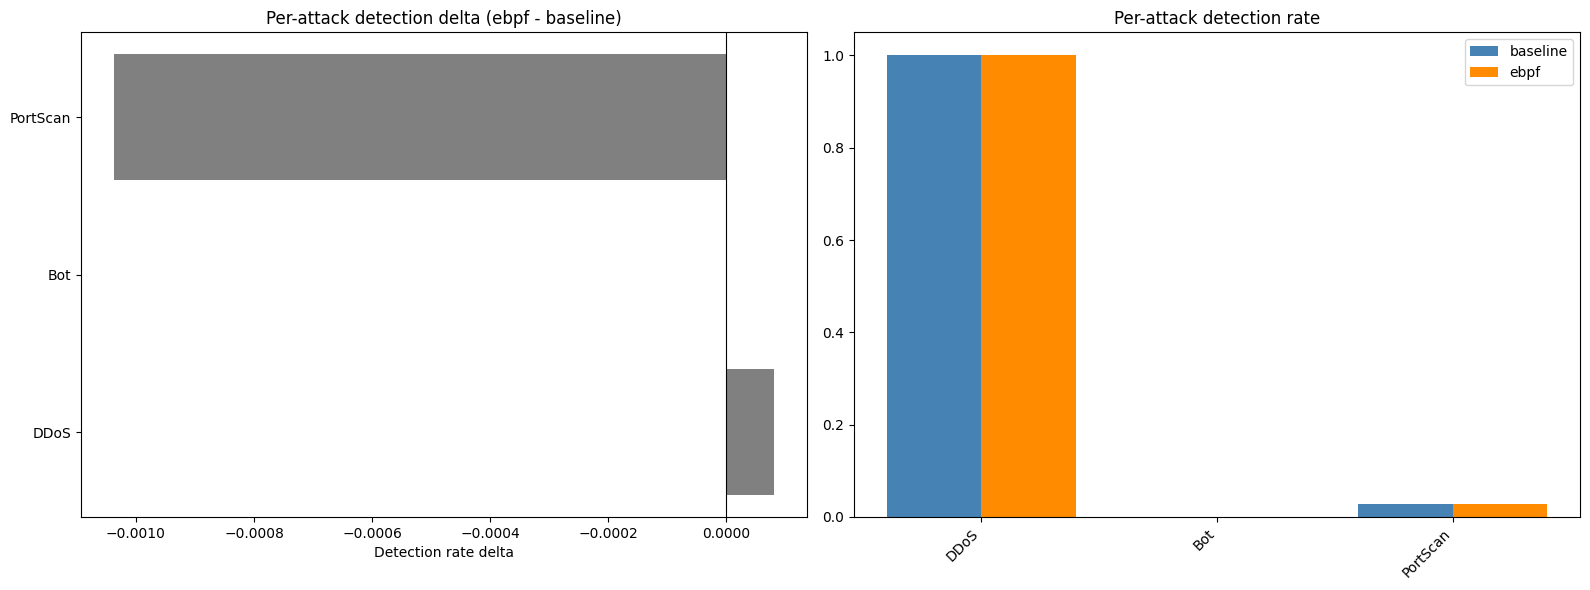

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delta chart
colors = ['darkorange' if x > 0.01 else ('steelblue' if x < -0.01 else 'grey') for x in merged['delta']]
axes[0].barh(merged['attack'], merged['delta'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Per-attack detection delta (ebpf - baseline)')
axes[0].set_xlabel('Detection rate delta')

# Side-by-side rates
attacks = merged['attack'].tolist()
x = np.arange(len(attacks))
w = 0.4
bmap = dict(zip(merged['attack'], merged['detection_rate_baseline']))
emap = dict(zip(merged['attack'], merged['detection_rate_ebpf']))
axes[1].bar(x - w/2, [bmap[a] for a in attacks], w, label='baseline', color='steelblue')
axes[1].bar(x + w/2, [emap[a] for a in attacks], w, label='ebpf', color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(attacks, rotation=45, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Per-attack detection rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / f'per_attack_plots_headline_model_seed{RANDOM_SEED}.png', dpi=150)
plt.show()


## Delta heatmap: where does eBPF help?

In [4]:
def benchmark_inference(model, X: pd.DataFrame, n_runs: int = 5):
    _ = model.predict(X.iloc[: min(256, len(X))])
    lat = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        model.predict(X)
        lat.append(time.perf_counter() - t0)

    tracemalloc.start()
    model.predict(X)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        'mean_latency_s': float(np.mean(lat)),
        'std_latency_s': float(np.std(lat)),
        'per_sample_ms': float(np.mean(lat) / max(len(X), 1) * 1000),
        'peak_memory_mb': float(peak / 1024 / 1024),
        'n_samples': int(len(X)),
    }

bench = {}
for fs in ['baseline', 'ebpf']:
    b = benchmark_inference(PACKS[fs]['model'], DATA[fs]['X'])
    bench[fs] = b
    print(f"\n[*] {fs}")
    print(f"  latency: {b['mean_latency_s']*1000:.1f} +/- {b['std_latency_s']*1000:.1f} ms")
    print(f"  per-sample: {b['per_sample_ms']:.5f} ms")
    print(f"  peak memory: {b['peak_memory_mb']:.2f} MB")

(REPORTS_DIR / f'compute_benchmark_headline_model_seed{RANDOM_SEED}.json').write_text(json.dumps(bench, indent=2))
print(f"\n[+] Saved benchmark report to {REPORTS_DIR}")



[*] baseline
  latency: 2134.9 +/- 45.5 ms
  per-sample: 0.00391 ms
  peak memory: 83.35 MB

[*] ebpf
  latency: 2076.5 +/- 43.5 ms
  per-sample: 0.00380 ms
  peak memory: 141.69 MB

[+] Saved benchmark report to /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports
